In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import json
import wandb
import tensorflow as tf
from google.colab import userdata

BASE = '/content/drive/MyDrive/Ketastasia/data'

data = np.load(f'{BASE}/dataset_seq_33kp_ready.npz')
X_train, y_train, y_train_idx = data['X_train'], data['y_train'], data['y_train_int']
X_val,   y_val,   y_val_idx   = data['X_val'],   data['y_val'],   data['y_val_int']

with open(f'{BASE}/pipeline2A_metadata.json') as f:
    meta = json.load(f)

n_classes  = len(meta['classes'])
seq_len    = meta['sequence_length']
n_features = meta['n_features_per_frame']

print(f"Loaded: X_train {X_train.shape}, y_train (one-hot) {y_train.shape}, y_train_idx (int) {y_train_idx.shape}")

wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)

Mounted at /content/drive
Loaded: X_train (5579, 15, 72), y_train (one-hot) (5579, 26), y_train_idx (int) (5579,)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

os.makedirs(f'{BASE}/models', exist_ok=True)

classes = meta['classes']

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

def build_gru_baseline(hidden=64, n_layers=1, lr=0.001):
    model = Sequential()
    model.add(layers.Input(shape=(seq_len, n_features)))

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(layers.GRU(hidden, return_sequences=return_seq))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [4]:
configs = [
    {'name': 'small',  'hidden': 32,  'n_layers': 1, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'medium', 'hidden': 64,  'n_layers': 1, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'large',  'hidden': 128, 'n_layers': 2, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
]
print(f"მომზადებულია {len(configs)} capacity ვარიანტი (small/medium/large)")

მომზადებულია 3 capacity ვარიანტი (small/medium/large)


In [6]:
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

best_val_acc = 0
best_run_name = None
baseline_results = []

for cfg in configs:
    run_name = f"gru_baseline_{cfg['name']}"
    architecture_name = f"GRU-baseline-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting Baseline experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            **cfg,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': False,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_baseline(
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix (Baseline) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    baseline_results.append({
        'run_name': run_name, 'hidden': cfg['hidden'], 'n_layers': cfg['n_layers'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_run_name = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

baseline_df = pd.DataFrame(baseline_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nBaseline experiments completed!\n{'='*60}")
print(baseline_df[['run_name', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name} (Val Acc: {best_val_acc:.4f})")


------------------------------------------------------------
Starting Baseline experiment: gru_baseline_small
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3859 - loss: 2.1894 - val_accuracy: 0.3975 - val_loss: 2.0177 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5938 - loss: 1.3274 - val_accuracy: 0.4973 - val_loss: 1.6342 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7161 - loss: 0.9534 - val_accuracy: 0.5526 - val_loss: 1.4797 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7788 - loss: 0.7550 - val_accuracy: 0.5835 - val_loss: 1.4238 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8129 - loss: 0.6284 - val_accuracy: 0.6134 - val_loss: 1.4515 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8403 - loss: 0.5325 - val_accuracy: 0.6098 - val_loss: 1.4336 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8595 - loss: 0.4645

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_baseline_small completed. Val Accuracy: 0.6452, Gap: 0.2738


epoch/accuracy,▁▄▅▆▆▇▇▇▇████████████
epoch/epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
epoch/learning_rate,████████▄▄▄▄▂▂▂▂▁▁▁▁▁
epoch/loss,█▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▆▇▇▇██████████████
epoch/val_loss,█▃▂▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.5318 - loss: 1.6031 - val_accuracy: 0.5299 - val_loss: 1.5385 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7724 - loss: 0.7201 - val_accuracy: 0.6316 - val_loss: 1.3691 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.8510 - loss: 0.4675 - val_accuracy: 0.6425 - val_loss: 1.4552 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9007 - loss: 0.3262 - val_accuracy: 0.6497 - val_loss: 1.4337 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9183 - loss: 0.2524 - val_accuracy: 0.6615 - val_loss: 1.5830 - learning_rate: 0.0010
Epoch 6/40
174/175 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9327 - loss: 0.2163
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9367 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_baseline_large completed. Val Accuracy: 0.6788, Gap: 0.2913


epoch/accuracy,▁▅▆▇▇▇█████████
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,██████▄▄▄▄▂▂▂▂▁
epoch/loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▆▆▇▇▆███▇███▇█
epoch/val_loss,▃▁▂▂▄▄▄▅▆▆▇▇▇██
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Baseline experiments completed!
              run_name  train_acc   val_acc       gap  val_loss  val_f1_macro
1  gru_baseline_medium   0.940670  0.682396  0.258275  1.455030      0.567805
2   gru_baseline_large   0.970066  0.678766  0.291300  1.625014      0.568290
0   gru_baseline_small   0.918982  0.645191  0.273791  1.569163      0.544680

Best: gru_baseline_medium (Val Acc: 0.6824)


In [7]:
def build_gru_dropout(dropout_rate, hidden=64, n_layers=1, lr=0.001):
    model = Sequential()
    model.add(layers.Input(shape=(seq_len, n_features)))

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(layers.GRU(
            hidden,
            return_sequences=return_seq,
            dropout=dropout_rate,
            recurrent_dropout=dropout_rate
        ))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [8]:
configs_dropout = [
    {'name': 'dropout_0.1', 'hidden': 64, 'n_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.2', 'hidden': 64, 'n_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.3', 'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.4', 'hidden': 64, 'n_layers': 1, 'dropout': 0.4, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.5', 'hidden': 64, 'n_layers': 1, 'dropout': 0.5, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
    {'name': 'dropout_0.8', 'hidden': 64, 'n_layers': 1, 'dropout': 0.8, 'lr': 0.001, 'batch_size': 32, 'epochs': 40},
]
print(f"Prepared {len(configs_dropout)} dropout values (capacity fixed: hidden=64, n_layers=1)")

Prepared 6 dropout values (capacity fixed: hidden=64, n_layers=1)


In [9]:
best_val_acc_dropout = 0
best_run_name_dropout = None
dropout_results = []

for cfg in configs_dropout:
    run_name = f"gru_{cfg['name']}"
    architecture_name = f"GRU-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting Dropout experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            **cfg,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_dropout(
        dropout_rate=cfg['dropout'],
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix (Dropout) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    dropout_results.append({
        'run_name': run_name, 'dropout': cfg['dropout'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_dropout:
        best_val_acc_dropout = val_acc
        best_run_name_dropout = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

dropout_df = pd.DataFrame(dropout_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nDropout sweep completed!\n{'='*60}")
print(dropout_df[['run_name', 'dropout', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_dropout} (Val Acc: {best_val_acc_dropout:.4f})")


------------------------------------------------------------
Starting Dropout experiment: gru_dropout_0.1
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3954 - loss: 2.0796 - val_accuracy: 0.4583 - val_loss: 1.7641 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6112 - loss: 1.2372 - val_accuracy: 0.5744 - val_loss: 1.4666 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7059 - loss: 0.9394 - val_accuracy: 0.6134 - val_loss: 1.3715 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7489 - loss: 0.8004 - val_accuracy: 0.6252 - val_loss: 1.3085 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7761 - loss: 0.6959 - val_accuracy: 0.6397 - val_loss: 1.2814 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8030 - loss: 0.6266 - val_accuracy: 0.6461 - val_loss: 1.2997 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8209 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_dropout_0.1 completed. Val Accuracy: 0.6742, Gap: 0.2354


epoch/accuracy,▁▄▅▆▆▆▇▇▇▇▇█████████████████
epoch/epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
epoch/learning_rate,███████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁
epoch/loss,█▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▅▆▆▇▇▇▇▇█▇▇██▇█████████████
epoch/val_loss,█▄▂▁▁▁▁▂▂▁▂▂▃▃▃▃▄▃▄▃▄▄▄▄▄▄▄▄
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0828 - loss: 3.4192 - val_accuracy: 0.2595 - val_loss: 2.7283 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.1608 - loss: 2.9547 - val_accuracy: 0.2641 - val_loss: 2.5654 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2052 - loss: 2.7757 - val_accuracy: 0.2886 - val_loss: 2.4601 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.2244 - loss: 2.6502 - val_accuracy: 0.3022 - val_loss: 2.3832 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2432 - loss: 2.5573 - val_accuracy: 0.3004 - val_loss: 2.2941 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.2572 - loss: 2.5075 - val_accuracy: 0.3203 - val_loss: 2.2222 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2705 - loss: 2.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_dropout_0.8 completed. Val Accuracy: 0.4338, Gap: -0.0505


epoch/accuracy,▁▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,█████████████████████████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇█▇████
epoch/val_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Dropout sweep completed!
          run_name  dropout  train_acc   val_acc       gap  val_loss  \
2  gru_dropout_0.3      0.3   0.845671  0.678766  0.166905  1.371721   
0  gru_dropout_0.1      0.1   0.909661  0.674229  0.235433  1.444028   
1  gru_dropout_0.2      0.2   0.884926  0.667877  0.217049  1.467306   
3  gru_dropout_0.4      0.4   0.762681  0.645191  0.117491  1.373127   
4  gru_dropout_0.5      0.5   0.755512  0.620690  0.134822  1.422250   
5  gru_dropout_0.8      0.8   0.383223  0.433757 -0.050534  1.871985   

   val_f1_macro  
2      0.560352  
0      0.569963  
1      0.553212  
3      0.523264  
4      0.507920  
5      0.292902  

Best: gru_dropout_0.3 (Val Acc: 0.6788)


In [10]:
configs_lr = [
    {'name': 'lr_0.01_d0.3',    'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.01,    'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.001_d0.3',   'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001,   'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0005_d0.3',  'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0005,  'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0001_d0.3',  'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001,  'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.01_d0.4',    'hidden': 64, 'n_layers': 1, 'dropout': 0.4, 'lr': 0.01,    'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.001_d0.4',   'hidden': 64, 'n_layers': 1, 'dropout': 0.4, 'lr': 0.001,   'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0005_d0.4',  'hidden': 64, 'n_layers': 1, 'dropout': 0.4, 'lr': 0.0005,  'batch_size': 32, 'epochs': 40},
    {'name': 'lr_0.0001_d0.4',  'hidden': 64, 'n_layers': 1, 'dropout': 0.4, 'lr': 0.0001,  'batch_size': 32, 'epochs': 40},
]
print(f"Prepared {len(configs_lr)} learning rate configs (dropout 0.3 and 0.4 both tested)")

Prepared 8 learning rate configs (dropout 0.3 and 0.4 both tested)


In [11]:
best_val_acc_lr = 0
best_run_name_lr = None
lr_results = []

for cfg in configs_lr:
    run_name = f"gru_{cfg['name']}"
    architecture_name = f"GRU-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting LR experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            **cfg,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_dropout(
        dropout_rate=cfg['dropout'],
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix (LR sweep) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    lr_results.append({
        'run_name': run_name, 'lr': cfg['lr'], 'dropout': cfg['dropout'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_lr:
        best_val_acc_lr = val_acc
        best_run_name_lr = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

lr_df = pd.DataFrame(lr_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nLearning Rate sweep completed!\n{'='*60}")
print(lr_df[['run_name', 'lr', 'dropout', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_lr} (Val Acc: {best_val_acc_lr:.4f})")


------------------------------------------------------------
Starting LR experiment: gru_lr_0.01_d0.3
------------------------------------------------------------


Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4691 - loss: 1.6790 - val_accuracy: 0.5136 - val_loss: 1.6115 - learning_rate: 0.0100
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6356 - loss: 1.0991 - val_accuracy: 0.5744 - val_loss: 1.5386 - learning_rate: 0.0100
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6845 - loss: 0.9735 - val_accuracy: 0.5735 - val_loss: 1.5932 - learning_rate: 0.0100
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7023 - loss: 0.9083 - val_accuracy: 0.5672 - val_loss: 1.6555 - learning_rate: 0.0100
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7116 - loss: 0.8785 - val_accuracy: 0.5626 - val_loss: 1.5509 - learning_rate: 0.0100
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7261 - loss: 0.8278 - val_accuracy: 0.5998 - val_loss: 1.4895 - learning_rate: 0.0100
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7514 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.01_d0.3 completed. Val Accuracy: 0.6525, Gap: 0.1982


epoch/accuracy,▁▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇███████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,██████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▄▄▃▅▅▆▃▅▆▆▇▆▇▆█▇█▇▇██▇███▇█▇████
epoch/val_loss,▄▂▃▄▂▁▄▅█▅▅▇▄▅▃▅▄▅▆▅▅▆▆▆▅▆▆▆▆▆▆▆▆▆
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.0787 - loss: 3.2280 - val_accuracy: 0.1788 - val_loss: 3.0119 - learning_rate: 1.0000e-04
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2020 - loss: 2.9028 - val_accuracy: 0.2505 - val_loss: 2.7542 - learning_rate: 1.0000e-04
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2633 - loss: 2.6696 - val_accuracy: 0.2677 - val_loss: 2.5746 - learning_rate: 1.0000e-04
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.2915 - loss: 2.4999 - val_accuracy: 0.2886 - val_loss: 2.4589 - learning_rate: 1.0000e-04
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3044 - loss: 2.4044 - val_accuracy: 0.3067 - val_loss: 2.3813 - learning_rate: 1.0000e-04
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3248 - loss: 2.3045 - val_accuracy: 0.3221 - val_loss: 2.3112 - learning_rate: 1.0000e-04
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - ac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.0001_d0.4 completed. Val Accuracy: 0.5009, Gap: 0.0634


epoch/accuracy,▁▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████
epoch/val_loss,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Learning Rate sweep completed!
             run_name      lr  dropout  train_acc   val_acc       gap  \
1   gru_lr_0.001_d0.3  0.0010      0.3   0.799068  0.688748  0.110320   
2  gru_lr_0.0005_d0.3  0.0005      0.3   0.799964  0.656080  0.143884   
0    gru_lr_0.01_d0.3  0.0100      0.3   0.850690  0.652450  0.198240   
5   gru_lr_0.001_d0.4  0.0010      0.4   0.802653  0.648820  0.153832   
6  gru_lr_0.0005_d0.4  0.0005      0.4   0.733823  0.642468  0.091355   
4    gru_lr_0.01_d0.4  0.0100      0.4   0.780785  0.617060  0.163725   
3  gru_lr_0.0001_d0.3  0.0001      0.3   0.627353  0.539020  0.088333   
7  gru_lr_0.0001_d0.4  0.0001      0.4   0.564259  0.500907  0.063351   

   val_loss  val_f1_macro  
1  1.335320      0.581829  
2  1.477810      0.551463  
0  1.710001      0.551306  
5  1.368247      0.541409  
6  1.348241      0.519979  
4  1.681092      0.510003  
3  1.461494      0.413226  
7  1.622819      0.357339  

Best: gru_lr_0.001_d0.3 (Val Acc: 0.6887)


In [14]:
configs_lr0001_extended = [
    {'name': 'lr_0.0001_d0.3_ext', 'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 32, 'epochs': 70},
    {'name': 'lr_0.0001_d0.4_ext', 'hidden': 64, 'n_layers': 1, 'dropout': 0.4, 'lr': 0.0001, 'batch_size': 32, 'epochs': 70},
]
print(f"Prepared {len(configs_lr0001_extended)} extended lr=0.0001 configs (70 epochs)")

Prepared 2 extended lr=0.0001 configs (70 epochs)


In [15]:
best_val_acc_ext = 0
best_run_name_ext = None
lr0001_ext_results = []

for cfg in configs_lr0001_extended:
    run_name = f"gru_{cfg['name']}"
    architecture_name = f"GRU-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting extended experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            **cfg,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_dropout(
        dropout_rate=cfg['dropout'],
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    lr0001_ext_results.append({
        'run_name': run_name, 'dropout': cfg['dropout'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_ext:
        best_val_acc_ext = val_acc
        best_run_name_ext = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

lr0001_ext_df = pd.DataFrame(lr0001_ext_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nExtended lr=0.0001 sweep completed!\n{'='*60}")
print(lr0001_ext_df[['run_name', 'dropout', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_ext} (Val Acc: {best_val_acc_ext:.4f})")


------------------------------------------------------------
Starting extended experiment: gru_lr_0.0001_d0.3_ext
------------------------------------------------------------


Epoch 1/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1256 - loss: 3.1389 - val_accuracy: 0.2169 - val_loss: 2.9929 - learning_rate: 1.0000e-04
Epoch 2/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.2309 - loss: 2.7913 - val_accuracy: 0.2740 - val_loss: 2.7176 - learning_rate: 1.0000e-04
Epoch 3/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2755 - loss: 2.5687 - val_accuracy: 0.3058 - val_loss: 2.5379 - learning_rate: 1.0000e-04
Epoch 4/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3083 - loss: 2.4011 - val_accuracy: 0.3203 - val_loss: 2.4037 - learning_rate: 1.0000e-04
Epoch 5/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.3350 - loss: 2.2746 - val_accuracy: 0.3385 - val_loss: 2.3096 - learning_rate: 1.0000e-04
Epoch 6/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3542 - loss: 2.1739 - val_accuracy: 0.3711 - val_loss: 2.2311 - learning_rate: 1.0000e-04
Epoch 7/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - ac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▂▂▃▃▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
epoch/val_loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



------------------------------------------------------------
Starting extended experiment: gru_lr_0.0001_d0.4_ext
------------------------------------------------------------


Epoch 1/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0810 - loss: 3.1884 - val_accuracy: 0.2486 - val_loss: 2.9170 - learning_rate: 1.0000e-04
Epoch 2/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2190 - loss: 2.8425 - val_accuracy: 0.2704 - val_loss: 2.6557 - learning_rate: 1.0000e-04
Epoch 3/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2660 - loss: 2.6102 - val_accuracy: 0.2849 - val_loss: 2.5090 - learning_rate: 1.0000e-04
Epoch 4/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2913 - loss: 2.4819 - val_accuracy: 0.3040 - val_loss: 2.4171 - learning_rate: 1.0000e-04
Epoch 5/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3103 - loss: 2.3784 - val_accuracy: 0.3094 - val_loss: 2.3492 - learning_rate: 1.0000e-04
Epoch 6/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3287 - loss: 2.3040 - val_accuracy: 0.3385 - val_loss: 2.2921 - learning_rate: 1.0000e-04
Epoch 7/70
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▂▂▂▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▆▇▆▇▇▇▇▇▇▇▇▇▇██████
epoch/epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▂▃▃▃▃▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██
epoch/val_loss,█▆▆▅▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Extended lr=0.0001 sweep completed!
                 run_name  dropout  train_acc   val_acc       gap  val_loss  \
0  gru_lr_0.0001_d0.3_ext      0.3   0.718050  0.627949  0.090101  1.430299   
1  gru_lr_0.0001_d0.4_ext      0.4   0.655673  0.579855  0.075818  1.460893   

   val_f1_macro  
0      0.502161  
1      0.458722  

Best: gru_lr_0.0001_d0.3_ext (Val Acc: 0.6279)


In [17]:
print(f"n_classes (expected): {n_classes}")
print(f"unique classes in y_train_idx: {len(np.unique(y_train_idx))}")
print(f"y_train_idx unique values: {sorted(np.unique(y_train_idx))}")

missing_classes = set(np.arange(n_classes)) - set(np.unique(y_train_idx))
print(f"Missing classes: {missing_classes}")

if missing_classes:
    for idx in missing_classes:
        print(f"  Missing class index {idx}: {classes[idx]}")

n_classes (expected): 26
unique classes in y_train_idx: 25
y_train_idx unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Missing classes: {np.int64(10)}
  Missing class index 10: jumping_jacks


In [19]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes_in_train = np.unique(y_train_idx)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes_in_train,
    y=y_train_idx
)

class_weight_dict_balanced = {i: 1.0 for i in range(n_classes)}
for idx, weight in zip(unique_classes_in_train, class_weights_arr):
    class_weight_dict_balanced[idx] = weight

class_weight_dict_sqrt = {i: np.sqrt(w) for i, w in class_weight_dict_balanced.items()}

print("Balanced weights:")
for i, cls in enumerate(classes):
    print(f"  {i} {cls}: {class_weight_dict_balanced[i]:.3f}")

print("\nSqrt-balanced weights:")
for i, cls in enumerate(classes):
    print(f"  {i} {cls}: {class_weight_dict_sqrt[i]:.3f}")

configs_classweight = [
    {'name': 'classweight_balanced', 'weight_dict': class_weight_dict_balanced},
    {'name': 'classweight_sqrt',     'weight_dict': class_weight_dict_sqrt},
]

print(f"\nPrepared {len(configs_classweight)} class weight strategies")

Balanced weights:
  0 bench_press: 1.162
  1 bicep_curl: 1.352
  2 chest_fly: 1.907
  3 clean_and_jerk: 0.341
  4 deadlift: 1.891
  5 decline_bench_press: 2.861
  6 hammer_curl: 1.336
  7 hip_thrust: 1.800
  8 incline_bench_press: 1.344
  9 jump_rope: 9.703
  10 jumping_jacks: 1.000
  11 lat_pulldown: 1.478
  12 lateral_raise: 0.930
  13 leg_extension: 1.352
  14 leg_raises: 1.261
  15 plank: 0.551
  16 pullup: 0.595
  17 pushup: 0.634
  18 romanian_deadlift: 1.478
  19 russian_twist: 1.459
  20 shoulder_press: 1.431
  21 situp: 1.313
  22 squat: 0.329
  23 t_bar_row: 0.954
  24 tricep_dips: 1.010
  25 tricep_pushdown: 1.539

Sqrt-balanced weights:
  0 bench_press: 1.078
  1 bicep_curl: 1.163
  2 chest_fly: 1.381
  3 clean_and_jerk: 0.584
  4 deadlift: 1.375
  5 decline_bench_press: 1.691
  6 hammer_curl: 1.156
  7 hip_thrust: 1.342
  8 incline_bench_press: 1.159
  9 jump_rope: 3.115
  10 jumping_jacks: 1.000
  11 lat_pulldown: 1.216
  12 lateral_raise: 0.964
  13 leg_extension: 1.163


In [20]:
best_val_acc_cw = 0
best_run_name_cw = None
classweight_results = []

for cw_cfg in configs_classweight:
    run_name = f"gru_lr_0.001_d0.3_{cw_cfg['name']}"
    architecture_name = f"GRU-lr_0.001_d0.3-{cw_cfg['name']}"

    print(f"\n{'-'*60}\nStarting experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001,
            'batch_size': 32, 'epochs': 60,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': True,
            'class_weight_strategy': cw_cfg['name'],
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_dropout(dropout_rate=0.3, hidden=64, n_layers=1, lr=0.001)

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=32,
        class_weight=cw_cfg['weight_dict'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix ({cw_cfg["name"]}) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    classweight_results.append({
        'run_name': run_name, 'strategy': cw_cfg['name'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_cw:
        best_val_acc_cw = val_acc
        best_run_name_cw = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}, F1_macro: {report_val['macro avg']['f1-score']:.4f}")
    wandb.finish()

classweight_df = pd.DataFrame(classweight_results).sort_values('val_f1_macro', ascending=False)
print(f"\n{'='*60}\nClass weight strategies completed!\n{'='*60}")
print(classweight_df[['run_name', 'strategy', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_cw}")


------------------------------------------------------------
Starting experiment: gru_lr_0.001_d0.3_classweight_balanced
------------------------------------------------------------


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.2414 - loss: 2.6358 - val_accuracy: 0.3521 - val_loss: 2.1761 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3821 - loss: 1.9092 - val_accuracy: 0.4483 - val_loss: 1.8635 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4639 - loss: 1.6127 - val_accuracy: 0.4619 - val_loss: 1.7697 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5142 - loss: 1.4025 - val_accuracy: 0.4882 - val_loss: 1.6895 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5539 - loss: 1.2795 - val_accuracy: 0.5381 - val_loss: 1.6002 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5913 - loss: 1.1744 - val_accuracy: 0.5508 - val_loss: 1.5617 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6161 - loss: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.001_d0.3_classweight_balanced completed. Val Accuracy: 0.6397, Gap: 0.1502, F1_macro: 0.5805


epoch/accuracy,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇███████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,██████████████████▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▄▆▆▆▆▆▆▇▆▇▇▇▇▇▇███▇██████████████
epoch/val_loss,█▅▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3002 - loss: 2.4039 - val_accuracy: 0.3666 - val_loss: 2.0546 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4420 - loss: 1.7445 - val_accuracy: 0.4419 - val_loss: 1.7744 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5397 - loss: 1.4322 - val_accuracy: 0.4864 - val_loss: 1.6318 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5922 - loss: 1.2457 - val_accuracy: 0.5000 - val_loss: 1.5952 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6302 - loss: 1.1182 - val_accuracy: 0.5245 - val_loss: 1.5283 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6598 - loss: 1.0135 - val_accuracy: 0.5626 - val_loss: 1.4906 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6863 - loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.001_d0.3_classweight_sqrt completed. Val Accuracy: 0.6652, Gap: 0.1681, F1_macro: 0.5650


epoch/accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
epoch/learning_rate,██████████████▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▄▅▆▆▆▇▇▇▇▇▇▇▇████████████████████████
epoch/val_loss,█▅▄▃▂▂▂▂▁▁▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Class weight strategies completed!
                                 run_name              strategy  train_acc  \
0  gru_lr_0.001_d0.3_classweight_balanced  classweight_balanced   0.789927   
1      gru_lr_0.001_d0.3_classweight_sqrt      classweight_sqrt   0.833303   

    val_acc       gap  val_loss  val_f1_macro  
0  0.639746  0.150181  1.463121      0.580474  
1  0.665154  0.168149  1.512302      0.564999  

Best: gru_lr_0.001_d0.3_classweight_sqrt


In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
import wandb
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

configs_batch_size = [
    {'name': 'bs16_d0.3_e50', 'hidden': 128, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16, 'epochs': 50},
    {'name': 'bs64_d0.3_e50', 'hidden': 128, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'epochs': 50},
]

print(f"Prepared {len(configs_batch_size)} batch size sweep configs (50 epochs)")

best_val_acc_bs = 0
best_run_name_bs = None
gru_bs_results = []

for cfg in configs_batch_size:
    run_name = f"gru_{cfg['name']}"
    architecture_name = f"GRU-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting batch size experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            **cfg,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_dropout(
        dropout_rate=cfg['dropout'],
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    gru_bs_results.append({
        'run_name': run_name, 'batch_size': cfg['batch_size'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_bs:
        best_val_acc_bs = val_acc
        best_run_name_bs = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

gru_bs_df = pd.DataFrame(gru_bs_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nBatch size sweep completed!\n{'='*60}")
print(gru_bs_df[['run_name', 'batch_size', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_bs} (Val Acc: {best_val_acc_bs:.4f})")

Prepared 2 batch size sweep configs (50 epochs)

------------------------------------------------------------
Starting batch size experiment: gru_bs16_d0.3_e50
------------------------------------------------------------


Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3895 - loss: 2.0065 - val_accuracy: 0.4673 - val_loss: 1.6944 - learning_rate: 0.0010
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.5628 - loss: 1.3771 - val_accuracy: 0.5372 - val_loss: 1.4735 - learning_rate: 0.0010
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.6374 - loss: 1.1122 - val_accuracy: 0.5907 - val_loss: 1.3796 - learning_rate: 0.0010
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.6915 - loss: 0.9517 - val_accuracy: 0.5989 - val_loss: 1.4100 - learning_rate: 0.0010
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7215 - loss: 0.8338 - val_accuracy: 0.6207 - val_loss: 1.3771 - learning_rate: 0.0010
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.7591 - loss: 0.7383 - val_accuracy: 0.6434 - val_loss: 1.3559 - learning_rate: 0.0010
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.7897 - l

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,████████████▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch/loss,█▆▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▅▅▆▇▇▇▇▇▇▇█▇██▇▇████▇▇█████████████
epoch/val_loss,▇▃▁▂▁▁▁▁▃▃▄▄▄▅▅▆▅▆▆▆▇▇▇█▇▇▇██▇███████
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



------------------------------------------------------------
Starting batch size experiment: gru_bs64_d0.3_e50
------------------------------------------------------------


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.3165 - loss: 2.3299 - val_accuracy: 0.4047 - val_loss: 1.9723 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4662 - loss: 1.6906 - val_accuracy: 0.4800 - val_loss: 1.6554 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.5551 - loss: 1.4026 - val_accuracy: 0.5254 - val_loss: 1.5768 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.6173 - loss: 1.2156 - val_accuracy: 0.5517 - val_loss: 1.5024 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6481 - loss: 1.0774 - val_accuracy: 0.5690 - val_loss: 1.4604 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6854 - loss: 0.9872 - val_accuracy: 0.5935 - val_loss: 1.4462 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7044 - loss: 0.9013 - val_ac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▃▄▅▅▆▆▆▇▇▇▇▇▇▇█▇███████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,█████████████▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▅▅▆▆▆▇▇▇▇▇▇██████████████████████████
epoch/val_loss,█▄▃▂▂▁▂▁▂▁▁▁▂▁▁▁▁▂▂▁▂▁▂▂▂▂▁▁▂▂▂▂▂▂▂▂▁▁▁▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Batch size sweep completed!
            run_name  batch_size  train_acc   val_acc       gap  val_loss  \
1  gru_bs64_d0.3_e50          64   0.872916  0.680581  0.192336  1.434570   
0  gru_bs16_d0.3_e50          16   0.903925  0.676951  0.226974  1.665623   

   val_f1_macro  
1      0.586360  
0      0.565809  

Best: gru_bs64_d0.3_e50 (Val Acc: 0.6806)


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
import wandb
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Focus completely on hidden=64 with both batch sizes
configs_hidden_64 = [
    {'name': 'bs16_h64_e50', 'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16, 'epochs': 50},
    {'name': 'bs64_h64_e50', 'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64, 'epochs': 50},
]

print(f"Prepared {len(configs_hidden_64)} configs with hidden=64 (50 epochs)")

best_val_acc_h64 = 0
best_run_name_h64 = None
gru_h64_results = []

for cfg in configs_hidden_64:
    run_name = f"gru_{cfg['name']}"
    architecture_name = f"GRU-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting experiment: {run_name} (Hidden: 64, BS: {cfg['batch_size']})\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            **cfg,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_dropout(
        dropout_rate=cfg['dropout'],
        hidden=cfg['hidden'],
        n_layers=cfg['n_layers'],
        lr=cfg['lr']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    gru_h64_results.append({
        'run_name': run_name, 'batch_size': cfg['batch_size'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_h64:
        best_val_acc_h64 = val_acc
        best_run_name_h64 = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

gru_h64_df = pd.DataFrame(gru_h64_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nHidden=64 sweep completed!\n{'='*60}")
print(gru_h64_df[['run_name', 'batch_size', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest from this run: {best_run_name_h64} (Val Acc: {best_val_acc_h64:.4f})")

Prepared 2 configs with hidden=64 (50 epochs)

------------------------------------------------------------
Starting experiment: gru_bs16_h64_e50 (Hidden: 64, BS: 16)
------------------------------------------------------------


Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3497 - loss: 2.2048 - val_accuracy: 0.4456 - val_loss: 1.8270 - learning_rate: 0.0010
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.5168 - loss: 1.4962 - val_accuracy: 0.5100 - val_loss: 1.5502 - learning_rate: 0.0010
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5978 - loss: 1.2398 - val_accuracy: 0.5617 - val_loss: 1.4814 - learning_rate: 0.0010
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.6539 - loss: 1.0776 - val_accuracy: 0.5672 - val_loss: 1.4266 - learning_rate: 0.0010
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6865 - loss: 0.9718 - val_accuracy: 0.5889 - val_loss: 1.3664 - learning_rate: 0.0010
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7053 - loss: 0.8967 - val_accuracy: 0.6044 - val_loss: 1.3734 - learning_rate: 0.0010
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7304 - loss:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇███████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,█████████████████▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇███████████████████
epoch/val_loss,█▄▃▃▂▂▁▁▂▁▁▁▁▁▁▂▃▂▂▂▂▂▃▂▂▂▂▂▂▂▂▂▂▃▃▃
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



------------------------------------------------------------
Starting experiment: gru_bs64_h64_e50 (Hidden: 64, BS: 64)
------------------------------------------------------------


Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2630 - loss: 2.5947 - val_accuracy: 0.3403 - val_loss: 2.1905 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4209 - loss: 1.8954 - val_accuracy: 0.4374 - val_loss: 1.9480 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4886 - loss: 1.6390 - val_accuracy: 0.4701 - val_loss: 1.7873 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5402 - loss: 1.4465 - val_accuracy: 0.4982 - val_loss: 1.6689 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5824 - loss: 1.2994 - val_accuracy: 0.5245 - val_loss: 1.5735 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6159 - loss: 1.1745 - val_accuracy: 0.5490 - val_loss: 1.5316 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6356 - loss: 1.1024 - val_acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

epoch/accuracy,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇█████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,███████████████████▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▄▅▅▆▆▆▆▆▇▇▇▇█▇▇██████████████████████
epoch/val_loss,█▆▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Hidden=64 sweep completed!
           run_name  batch_size  train_acc   val_acc       gap  val_loss  \
0  gru_bs16_h64_e50          16   0.850511  0.676951  0.173560  1.394963   
1  gru_bs64_h64_e50          64   0.811615  0.667877  0.143738  1.346532   

   val_f1_macro  
0      0.581845  
1      0.562015  

Best from this run: gru_bs16_h64_e50 (Val Acc: 0.6770)


In [28]:
from tensorflow.keras.regularizers import l2

def build_gru_l2(dropout_rate, l2_lambda, hidden=64, n_layers=1, lr=0.001):
    model = Sequential()
    model.add(layers.Input(shape=(seq_len, n_features)))

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(layers.GRU(
            hidden,
            return_sequences=return_seq,
            dropout=dropout_rate,
            recurrent_dropout=dropout_rate,
            kernel_regularizer=l2(l2_lambda),
            recurrent_regularizer=l2(l2_lambda)
        ))

    model.add(layers.Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [29]:
configs_l2 = [
    {'name': 'l2_0.0001', 'l2_lambda': 0.0001},
    {'name': 'l2_0.001',  'l2_lambda': 0.001},
    {'name': 'l2_0.01',   'l2_lambda': 0.01},
]
print(f"Prepared {len(configs_l2)} L2 regularization values (dropout=0.3 fixed)")

Prepared 3 L2 regularization values (dropout=0.3 fixed)


In [30]:
best_val_acc_l2 = 0
best_run_name_l2 = None
l2_results = []

for cfg in configs_l2:
    run_name = f"gru_lr_0.001_d0.3_{cfg['name']}"
    architecture_name = f"GRU-lr_0.001_d0.3-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting L2 experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'lr': 0.001,
            'l2_lambda': cfg['l2_lambda'],
            'batch_size': 32, 'epochs': 60,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'l2_included': True,
            'class_weights_included': False,
            'seq_len': seq_len,
            'n_features': n_features,
            'n_classes': n_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_l2(
        dropout_rate=0.3,
        l2_lambda=cfg['l2_lambda'],
        hidden=64, n_layers=1, lr=0.001
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix ({cfg["name"]}) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    l2_results.append({
        'run_name': run_name, 'l2_lambda': cfg['l2_lambda'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_l2:
        best_val_acc_l2 = val_acc
        best_run_name_l2 = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}, F1_macro: {report_val['macro avg']['f1-score']:.4f}")
    wandb.finish()

l2_df = pd.DataFrame(l2_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nL2 regularization sweep completed!\n{'='*60}")
print(l2_df[['run_name', 'l2_lambda', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_l2} (Val Acc: {best_val_acc_l2:.4f})")


------------------------------------------------------------
Starting L2 experiment: gru_lr_0.001_d0.3_l2_0.0001
------------------------------------------------------------


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3311 - loss: 2.3528 - val_accuracy: 0.4065 - val_loss: 1.9659 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4653 - loss: 1.7185 - val_accuracy: 0.5018 - val_loss: 1.7120 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5352 - loss: 1.4585 - val_accuracy: 0.5463 - val_loss: 1.5653 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5885 - loss: 1.2899 - val_accuracy: 0.5544 - val_loss: 1.5103 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6247 - loss: 1.1770 - val_accuracy: 0.5608 - val_loss: 1.4621 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6632 - loss: 1.0726 - val_accuracy: 0.5780 - val_loss: 1.4509 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6863 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.001_d0.3_l2_0.0001 completed. Val Accuracy: 0.6906, Gap: 0.1703, F1_macro: 0.5909


epoch/accuracy,▁▃▄▄▅▆▆▆▇▇▇▇▇▇▇█████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,████████████████▄▄▄▄▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇██████████████████████████
epoch/val_loss,█▅▃▃▂▂▂▂▁▂▂▁▁▁▂▂▁▂▁▁▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


...

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3121 - loss: 3.6590 - val_accuracy: 0.3848 - val_loss: 2.8603 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4440 - loss: 2.4269 - val_accuracy: 0.4437 - val_loss: 2.3725 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4865 - loss: 2.0779 - val_accuracy: 0.4574 - val_loss: 2.1710 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5082 - loss: 1.9101 - val_accuracy: 0.4655 - val_loss: 2.0441 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5453 - loss: 1.7872 - val_accuracy: 0.4864 - val_loss: 1.9698 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5542 - loss: 1.6964 - val_accuracy: 0.4982 - val_loss: 1.9471 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5750 - loss: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.001_d0.3_l2_0.01 completed. Val Accuracy: 0.6361, Gap: 0.1115, F1_macro: 0.5068


epoch/accuracy,▁▃▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇███▇████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,████████████████████▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
epoch/loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▃▄▄▅▅▅▅▆▆▇▆▇▇▇▇▇▇▇▇█▇███▇████████████
epoch/val_loss,█▅▄▃▃▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



L2 regularization sweep completed!
                      run_name  l2_lambda  train_acc   val_acc       gap  \
0  gru_lr_0.001_d0.3_l2_0.0001     0.0001   0.860907  0.690563  0.170344   
1   gru_lr_0.001_d0.3_l2_0.001     0.0010   0.842803  0.677858  0.164945   
2    gru_lr_0.001_d0.3_l2_0.01     0.0100   0.747625  0.636116  0.111509   

   val_loss  val_f1_macro  
0  1.441341      0.590885  
1  1.579866      0.567774  
2  1.704655      0.506829  

Best: gru_lr_0.001_d0.3_l2_0.0001 (Val Acc: 0.6906)


In [31]:
# =====================================================================
# Cell: GRU Optimizer Sweep on Top of the New Champion (Hidden 64, L2 0.0001)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import wandb
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Dataset shapes safety setup
computed_num_classes = int(y_train.shape[1])
input_shape_detected = (X_train.shape[1], X_train.shape[2])

def build_gru_optimizer_sweep(dropout_rate, hidden, lr, input_shape, num_classes, l2_val, opt_name):
    model = Sequential()
    reg = regularizers.l2(l2_val)

    model.add(GRU(hidden, dropout=dropout_rate, kernel_regularizer=reg, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    # Selecting the optimizer based on configuration
    if opt_name == 'adam':
        optimizer = Adam(learning_rate=lr)
    elif opt_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=lr)
    elif opt_name == 'sgd_momentum':
        optimizer = SGD(learning_rate=lr, momentum=0.9, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup the configuration list for optimizer variants
configs_opt = [
    {'name': 'opt_adam',         'opt_type': 'adam',         'lr': 0.001},
    {'name': 'opt_rmsprop',      'opt_type': 'rmsprop',      'lr': 0.001},
    {'name': 'opt_sgd_momentum', 'opt_type': 'sgd_momentum', 'lr': 0.01}, # SGD needs a slightly higher starting LR
]

print(f"Prepared {len(configs_opt)} optimizer sweep configs targeting the 0.6906 champion setup.")

best_val_acc_opt = 0
best_run_name_opt = None
opt_results = []

for cfg in configs_opt:
    run_name = f"gru_lr_0.001_d0.3_l2_0.0001_{cfg['name']}"
    architecture_name = f"GRU-lr_0.001_d0.3-l2_0.0001-{cfg['name']}"

    print(f"\n{'-'*60}\nStarting Optimizer experiment: {run_name}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'l2_lambda': 0.0001,
            'optimizer_type': cfg['opt_type'], 'lr': cfg['lr'],
            'batch_size': 32, 'epochs': 60,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'l2_included': True,
            'class_weights_included': False,
            'seq_len': input_shape_detected[0],
            'n_features': input_shape_detected[1],
            'n_classes': computed_num_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_gru_optimizer_sweep(
        dropout_rate=0.3,
        hidden=64,
        lr=cfg['lr'],
        input_shape=input_shape_detected,
        num_classes=computed_num_classes,
        l2_val=0.0001,
        opt_name=cfg['opt_type']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    # Confusion Matrix generation
    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix ({cfg["opt_type"]}) - {run_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    opt_results.append({
        'run_name': run_name, 'optimizer': cfg['opt_type'], 'lr': cfg['lr'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_opt:
        best_val_acc_opt = val_acc
        best_run_name_opt = run_name

    print(f"Run {run_name} completed. Val Accuracy: {val_acc:.4f}, Gap: {gap:.4f}")
    wandb.finish()

opt_df = pd.DataFrame(opt_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nOptimizer sweep completed!\n{'='*60}")
print(opt_df[['run_name', 'optimizer', 'lr', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])
print(f"\nBest: {best_run_name_opt} (Val Acc: {best_val_acc_opt:.4f})")

Prepared 3 optimizer sweep configs targeting the 0.6906 champion setup.

------------------------------------------------------------
Starting Optimizer experiment: gru_lr_0.001_d0.3_l2_0.0001_opt_adam
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3346 - loss: 2.2821 - val_accuracy: 0.4002 - val_loss: 1.9734 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4990 - loss: 1.6128 - val_accuracy: 0.4673 - val_loss: 1.6764 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5700 - loss: 1.3721 - val_accuracy: 0.5218 - val_loss: 1.5195 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6157 - loss: 1.2169 - val_accuracy: 0.5363 - val_loss: 1.4484 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6584 - loss: 1.0931 - val_accuracy: 0.5544 - val_loss: 1.4258 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6955 - loss: 0.9865 - val_accuracy: 0.6025 - val_loss: 1.3567 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7050 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.001_d0.3_l2_0.0001_opt_adam completed. Val Accuracy: 0.6661, Gap: 0.1488


...

175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3732 - loss: 2.1550 - val_accuracy: 0.4192 - val_loss: 1.9433 - learning_rate: 0.0100
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4920 - loss: 1.6441 - val_accuracy: 0.4592 - val_loss: 1.7778 - learning_rate: 0.0100
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5411 - loss: 1.4548 - val_accuracy: 0.4710 - val_loss: 1.6645 - learning_rate: 0.0100
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5802 - loss: 1.3260 - val_accuracy: 0.5390 - val_loss: 1.5174 - learning_rate: 0.0100
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5997 - loss: 1.2317 - val_accuracy: 0.5699 - val_loss: 1.4778 - learning_rate: 0.0100
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6383 - loss: 1.1378 - val_accuracy: 0.5563 - val_loss: 1.4150 - learning_rate: 0.0100
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6560 - loss: 1.0669 - val_

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Run gru_lr_0.001_d0.3_l2_0.0001_opt_sgd_momentum completed. Val Accuracy: 0.6688, Gap: 0.1781


epoch/accuracy,▁▃▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇█▇██████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
epoch/learning_rate,███████████████▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▂▄▅▅▆▇▇▇▇▇▇▇▇▇█▇██████████████████████
epoch/val_loss,█▆▅▄▃▃▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Optimizer sweep completed!
                                       run_name     optimizer     lr  \
1       gru_lr_0.001_d0.3_l2_0.0001_opt_rmsprop       rmsprop  0.001   
2  gru_lr_0.001_d0.3_l2_0.0001_opt_sgd_momentum  sgd_momentum  0.010   
0          gru_lr_0.001_d0.3_l2_0.0001_opt_adam          adam  0.001   

   train_acc   val_acc       gap  val_loss  val_f1_macro  
1   0.856605  0.684211  0.172395  1.310470      0.577420  
2   0.846926  0.668784  0.178142  1.244087      0.570495  
0   0.814841  0.666062  0.148780  1.317875      0.560617  

Best: gru_lr_0.001_d0.3_l2_0.0001_opt_rmsprop (Val Acc: 0.6842)


In [32]:
# =====================================================================
# Cell: GRU Deep Architecture Sweep - Bidirectional vs Stacked (Proper Dropout)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import wandb
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Core setup parameters extracted dynamically
computed_num_classes = int(y_train.shape[1])
input_shape_detected = (X_train.shape[1], X_train.shape[2])

def build_advanced_gru(hidden, dropout_rate, lr, input_shape, num_classes, l2_val, architecture_type):
    model = Sequential()
    reg = regularizers.l2(l2_val)

    if architecture_type == 'bidirectional':
        # Processing sequence from both sides simultaneously
        model.add(Bidirectional(GRU(hidden, dropout=dropout_rate, kernel_regularizer=reg), input_shape=input_shape))
        model.add(Dropout(dropout_rate))

    elif architecture_type == 'stacked':
        # Two consecutive layers with rigorous dropout control
        model.add(GRU(hidden, dropout=dropout_rate, kernel_regularizer=reg, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(dropout_rate))
        model.add(GRU(hidden, dropout=dropout_rate, kernel_regularizer=reg))
        model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Definition of the final structural experiments
configs_advanced = [
    {'name': 'bidirectional_h64', 'type': 'bidirectional'},
    {'name': 'stacked_h64_d0.3',   'type': 'stacked'},
]

print(f"Initialized structural sweep for: {[c['type'] for c in configs_advanced]}")

best_val_acc_adv = 0
best_run_name_adv = None
adv_results = []

for cfg in configs_advanced:
    run_name = f"gru_lr_0.001_d0.3_l2_0.0001_{cfg['name']}"
    architecture_name = f"GRU-lr_0.001_d0.3-l2_0.0001-{cfg['name']}"

    print(f"\n{'-'*60}\nRunning Structural Upgrade: {cfg['type'].upper()}\n{'-'*60}")

    wandb.init(
        project='ildolcefarniente',
        group='p2_gru',
        name=run_name,
        config={
            'hidden': 64, 'n_layers': 2 if cfg['type'] == 'stacked' else 1,
            'dropout': 0.3, 'l2_lambda': 0.0001, 'architecture_mode': cfg['type'],
            'batch_size': 32, 'epochs': 60, 'lr': 0.001,
            'model': 'gru',
            'architecture': architecture_name,
            'dropout_included': True,
            'l2_included': True,
            'class_weights_included': False,
            'seq_len': input_shape_detected[0],
            'n_features': input_shape_detected[1],
            'n_classes': computed_num_classes,
            'pipeline': 'pipeline2A_33kp',
            'normalization': 'hip_centered_shoulder_hip_scaled'
        },
        reinit=True
    )

    model = build_advanced_gru(
        hidden=64,
        dropout_rate=0.3,
        lr=0.001,
        input_shape=input_shape_detected,
        num_classes=computed_num_classes,
        l2_val=0.0001,
        architecture_type=cfg['type']
    )

    callbacks = [
        WandbMetricsLogger(log_freq='epoch'),
        EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    train_acc_at_best = history.history['accuracy'][best_epoch_idx]
    gap = train_acc_at_best - val_acc

    y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
    )

    # Generate and save Confusion Matrix plot
    cm_val = confusion_matrix(y_val_idx, y_pred_val)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'Val Confusion Matrix - {cfg["type"].upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Val Label')
    ax.set_xlabel('Predicted Val Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    cm_path = f'/content/{run_name}_val_cm.png'
    plt.savefig(cm_path, dpi=150)
    plt.close()

    wandb.log({
        'final_val_accuracy': val_acc,
        'final_val_loss': val_loss,
        'train_acc_at_best': train_acc_at_best,
        'overfitting_gap': gap,
        'val_f1_macro': report_val['macro avg']['f1-score'],
        'val_f1_weighted': report_val['weighted avg']['f1-score'],
        'val_confusion_matrix_db': wandb.plot.confusion_matrix(
            probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
        ),
        'val_confusion_matrix_img': wandb.Image(cm_path)
    })

    model_path = f'{BASE}/models/{run_name}.keras'
    model.save(model_path)

    adv_results.append({
        'run_name': run_name, 'type': cfg['type'],
        'train_acc': train_acc_at_best, 'val_acc': val_acc, 'gap': gap,
        'val_loss': val_loss, 'val_f1_macro': report_val['macro avg']['f1-score']
    })

    if val_acc > best_val_acc_adv:
        best_val_acc_adv = val_acc
        best_run_name_adv = run_name

    print(f"Completed {cfg['type'].upper()}. Val Accuracy: {val_acc:.4f}, Overfitting Gap: {gap:.4f}")
    wandb.finish()

adv_df = pd.DataFrame(adv_results).sort_values('val_acc', ascending=False)
print(f"\n{'='*60}\nDeep Architectural Sweep Completed!\n{'='*60}")
print(adv_df[['run_name', 'type', 'train_acc', 'val_acc', 'gap', 'val_loss', 'val_f1_macro']])

Initialized structural sweep for: ['bidirectional', 'stacked']

------------------------------------------------------------
Running Structural Upgrade: BIDIRECTIONAL
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3974 - loss: 2.0740 - val_accuracy: 0.4664 - val_loss: 1.8212 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.5705 - loss: 1.3852 - val_accuracy: 0.5100 - val_loss: 1.6107 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6560 - loss: 1.1387 - val_accuracy: 0.5572 - val_loss: 1.4735 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6924 - loss: 1.0018 - val_accuracy: 0.5789 - val_loss: 1.4049 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7249 - loss: 0.8921 - val_accuracy: 0.6143 - val_loss: 1.3572 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7455 - loss: 0.8144 - val_accuracy: 0.6261 - val_loss: 1.3654 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7625 - loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Completed BIDIRECTIONAL. Val Accuracy: 0.6733, Overfitting Gap: 0.1931


...

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.3348 - loss: 2.3034 - val_accuracy: 0.3938 - val_loss: 1.9669 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4802 - loss: 1.6989 - val_accuracy: 0.4755 - val_loss: 1.6651 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5393 - loss: 1.4498 - val_accuracy: 0.5381 - val_loss: 1.4949 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5892 - loss: 1.2880 - val_accuracy: 0.5626 - val_loss: 1.4293 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6239 - loss: 1.1930 - val_accuracy: 0.5508 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6523 - loss: 1.0874 - val_accuracy: 0.5871 - val_loss: 1.3683 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6783 - loss: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Completed STACKED. Val Accuracy: 0.6760, Overfitting Gap: 0.1408


epoch/accuracy,▁▃▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
epoch/learning_rate,█████████████▄▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▅▅▅▆▇▇▆▇▇▇▇▇▇███▇██▇██████████████████
epoch/val_loss,█▅▃▂▂▂▁▁▂▂▂▂▂▂▂▁▂▁▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...



Deep Architectural Sweep Completed!
                                        run_name           type  train_acc  \
1   gru_lr_0.001_d0.3_l2_0.0001_stacked_h64_d0.3        stacked   0.816813   
0  gru_lr_0.001_d0.3_l2_0.0001_bidirectional_h64  bidirectional   0.866464   

    val_acc       gap  val_loss  val_f1_macro  
1  0.676044  0.140769  1.364652      0.581000  
0  0.673321  0.193142  1.297921      0.587933  


In [33]:
# =====================================================================
# Cell: ULTIMATE GRU COMBINATION - Bidirectional + Label Smoothing
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import wandb
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Dataset metadata auto-setup
computed_num_classes = int(y_train.shape[1])
input_shape_detected = (X_train.shape[1], X_train.shape[2])

def build_ultimate_gru(hidden, dropout_rate, lr, input_shape, num_classes, l2_val, smoothing_val):
    model = Sequential()
    reg = regularizers.l2(l2_val)

    # Powerful Bidirectional core
    model.add(Bidirectional(GRU(hidden, dropout=dropout_rate, kernel_regularizer=reg), input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    # Soft loss function to suppress overfitting
    loss_fn = CategoricalCrossentropy(label_smoothing=smoothing_val)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

run_name = "gru_ultimate_bidirectional_smooth_0.1"
architecture_name = "GRU-Bidirectional-L2_0.0001-Smooth_0.1"

print(f"Launching the ultimate combination: {run_name}")
print(f"Config -> Input Shape: {input_shape_detected} | Label Smoothing: 0.1")

wandb.init(
    project='ildolcefarniente',
    group='p2_gru',
    name=run_name,
    config={
        'hidden': 64, 'n_layers': 1, 'dropout': 0.3, 'l2_lambda': 0.0001,
        'label_smoothing': 0.1, 'architecture_mode': 'bidirectional',
        'batch_size': 32, 'epochs': 60, 'lr': 0.001,
        'model': 'gru',
        'architecture': architecture_name,
        'dropout_included': True,
        'l2_included': True,
        'label_smoothing_included': True,
        'class_weights_included': False,
        'seq_len': input_shape_detected[0],
        'n_features': input_shape_detected[1],
        'n_classes': computed_num_classes,
        'pipeline': 'pipeline2A_33kp',
        'normalization': 'hip_centered_shoulder_hip_scaled'
    },
    reinit=True
)

model = build_ultimate_gru(
    hidden=64,
    dropout_rate=0.3,
    lr=0.001,
    input_shape=input_shape_detected,
    num_classes=computed_num_classes,
    l2_val=0.0001,
    smoothing_val=0.1
)

callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

best_epoch_idx = np.argmax(history.history['val_accuracy'])
train_acc_at_best = history.history['accuracy'][best_epoch_idx]
gap = train_acc_at_best - val_acc

y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

report_val = classification_report(
        y_val_idx, y_pred_val,
        labels=list(range(len(classes))),
        target_names=classes,
        output_dict=True
)

# Confusion Matrix for validation visualization
cm_val = confusion_matrix(y_val_idx, y_pred_val)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Val Confusion Matrix - ULTIMATE RUN', fontsize=12, fontweight='bold')
ax.set_ylabel('True Val Label')
ax.set_xlabel('Predicted Val Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
cm_path = f'/content/{run_name}_val_cm.png'
plt.savefig(cm_path, dpi=150)
plt.close()

wandb.log({
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'train_acc_at_best': train_acc_at_best,
    'overfitting_gap': gap,
    'val_f1_macro': report_val['macro avg']['f1-score'],
    'val_f1_weighted': report_val['weighted avg']['f1-score'],
    'val_confusion_matrix_db': wandb.plot.confusion_matrix(
        probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
    ),
    'val_confusion_matrix_img': wandb.Image(cm_path)
})

model_path = f'{BASE}/models/{run_name}.keras'
model.save(model_path)

print(f"\n{'='*60}\nUltimate Combination Completed!\n{'='*60}")
print(f"Run Name: {run_name}")
print(f"Train Acc at Best Epoch: {train_acc_at_best:.4f}")
print(f"Validation Accuracy:     {val_acc:.4f}")
print(f"Overfitting Gap:         {gap:.4f}")
print(f"Validation F1 Macro:     {report_val['macro avg']['f1-score']:.4f}")
wandb.finish()

Launching the ultimate combination: gru_ultimate_bidirectional_smooth_0.1
Config -> Input Shape: (15, 72) | Label Smoothing: 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.4098 - loss: 2.2864 - val_accuracy: 0.4873 - val_loss: 2.0379 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5872 - loss: 1.7647 - val_accuracy: 0.5163 - val_loss: 1.8712 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6548 - loss: 1.5849 - val_accuracy: 0.5681 - val_loss: 1.7736 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6978 - loss: 1.4792 - val_accuracy: 0.5880 - val_loss: 1.7305 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7403 - loss: 1.3911 - val_accuracy: 0.5971 - val_loss: 1.6823 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7578 - loss: 1.3278 - val_accuracy: 0.6270 - val_loss: 1.6751 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7889 - loss: 1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me


Ultimate Combination Completed!
Run Name: gru_ultimate_bidirectional_smooth_0.1
Train Acc at Best Epoch: 0.8494
Validation Accuracy:     0.6652
Overfitting Gap:         0.1843
Validation F1 Macro:     0.5407


epoch/accuracy,▁▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇████████
epoch/epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
epoch/learning_rate,█████████████████▃▃▃▃▃▁▁
epoch/loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▄▅▅▇▇▇▇▇▇██▇██▇▇██▇███
epoch/val_loss,█▅▄▃▂▂▂▂▁▂▂▁▁▂▁▁▂▂▁▂▁▂▂▂
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


In [35]:
# =====================================================================
# Cell: Hybrid Sweep - BiLSTM + GRU (Champion Regs: Dropout 0.3, L2 0.0001)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import wandb
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Shapes setup
computed_num_classes = int(y_train.shape[1])
input_shape_detected = (X_train.shape[1], X_train.shape[2])

def build_hybrid_model(hidden, dropout_rate, lr, input_shape, num_classes, l2_val):
    model = Sequential()
    reg = regularizers.l2(l2_val)

    # Layer 1: Heavy contextual processing via BiLSTM
    model.add(Bidirectional(LSTM(hidden, dropout=dropout_rate, kernel_regularizer=reg, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(dropout_rate))

    # Layer 2: Fast aggregation via GRU
    model.add(GRU(hidden, dropout=dropout_rate, kernel_regularizer=reg))
    model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

run_name = "hybrid_bilstm_gru_lr_0.001_d0.3_l2_0.0001"
architecture_name = "Hybrid-BiLSTM-GRU-L2_0.0001"

print(f"\n{'-'*60}\nLaunching Hybrid Monster: {run_name}\n{'-'*60}")

wandb.init(
    project='ildolcefarniente',
    group='p2_gru',
    name=run_name,
    config={
        'hidden': 64, 'n_layers': 2, 'dropout': 0.3, 'l2_lambda': 0.0001,
        'architecture_mode': 'hybrid_bilstm_gru',
        'batch_size': 32, 'epochs': 60, 'lr': 0.001,
        'model': 'hybrid',
        'architecture': architecture_name,
        'dropout_included': True,
        'l2_included': True,
        'class_weights_included': False,
        'seq_len': input_shape_detected[0],
        'n_features': input_shape_detected[1],
        'n_classes': computed_num_classes,
        'pipeline': 'pipeline2A_33kp',
        'normalization': 'hip_centered_shoulder_hip_scaled'
    },
    reinit=True
)

model = build_hybrid_model(
    hidden=64,
    dropout_rate=0.3,
    lr=0.001,
    input_shape=input_shape_detected,
    num_classes=computed_num_classes,
    l2_val=0.0001
)

callbacks = [
    WandbMetricsLogger(log_freq='epoch'),
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

best_epoch_idx = np.argmax(history.history['val_accuracy'])
train_acc_at_best = history.history['accuracy'][best_epoch_idx]
gap = train_acc_at_best - val_acc

y_pred_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

report_val = classification_report(
    y_val_idx, y_pred_val,
    labels=list(range(len(classes))),
    target_names=classes,
    output_dict=True
)

# Confusion Matrix
cm_val = confusion_matrix(y_val_idx, y_pred_val)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Val Confusion Matrix - Hybrid BiLSTM+GRU', fontsize=12, fontweight='bold')
ax.set_ylabel('True Val Label')
ax.set_xlabel('Predicted Val Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
cm_path = f'/content/{run_name}_val_cm.png'
plt.savefig(cm_path, dpi=150)
plt.close()

wandb.log({
    'final_val_accuracy': val_acc,
    'final_val_loss': val_loss,
    'train_acc_at_best': train_acc_at_best,
    'overfitting_gap': gap,
    'val_f1_macro': report_val['macro avg']['f1-score'],
    'val_f1_weighted': report_val['weighted avg']['f1-score'],
    'val_confusion_matrix_db': wandb.plot.confusion_matrix(
        probs=None, y_true=y_val_idx.tolist(), preds=y_pred_val.tolist(), class_names=classes
    ),
    'val_confusion_matrix_img': wandb.Image(cm_path)
})

model_path = f'{BASE}/models/{run_name}.keras'
model.save(model_path)

print(f"\n{'='*60}\nHybrid BiLSTM + GRU Run Completed!\n{'='*60}")
print(f"Train Acc at Best: {train_acc_at_best:.4f}")
print(f"Val Accuracy:      {val_acc:.4f}")
print(f"Gap:               {gap:.4f}")
print(f"Val F1 Macro:      {report_val['macro avg']['f1-score']:.4f}")
wandb.finish()


------------------------------------------------------------
Launching Hybrid Monster: hybrid_bilstm_gru_lr_0.001_d0.3_l2_0.0001
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.3712 - loss: 2.1944 - val_accuracy: 0.4474 - val_loss: 1.7930 - learning_rate: 0.0010
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5686 - loss: 1.4200 - val_accuracy: 0.5463 - val_loss: 1.5287 - learning_rate: 0.0010
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6404 - loss: 1.1545 - val_accuracy: 0.5517 - val_loss: 1.4771 - learning_rate: 0.0010
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6885 - loss: 1.0150 - val_accuracy: 0.5926 - val_loss: 1.4513 - learning_rate: 0.0010
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7222 - loss: 0.9063 - val_accuracy: 0.6025 - val_loss: 1.4358 - learning_rate: 0.0010
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7507 - loss: 0.8384 - val_accuracy: 0.5898 - val_loss: 1.4387 - learning_rate: 0.0010
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.7661 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me


Hybrid BiLSTM + GRU Run Completed!
Train Acc at Best: 0.8862
Val Accuracy:      0.6770
Gap:               0.2092
Val F1 Macro:      0.5698


epoch/accuracy,▁▄▅▅▆▆▆▇▇▇▇▇▇▇██████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,████████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▄▅▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇████████████████████
epoch/val_loss,█▄▃▃▃▃▂▁▃▂▃▃▄▄▃▃▃▄▄▄▃▃▄▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄
final_val_accuracy,▁
final_val_loss,▁
overfitting_gap,▁
train_acc_at_best,▁
+2,...


In [38]:
import pandas as pd
import wandb

# 1. მიუთითე შენი პროექტის მისამართი
ENTITY = "akeke23-free-university-of-tbilisi-"
PROJECT = "ildolcefarniente"

api = wandb.Api()

# 2. წამოვიღოთ 'p2_gru' ჯგუფის ყველა რანი
print("WandB-დან მონაცემების წამოღება...")
runs = api.runs(
    path=f"{ENTITY}/{PROJECT}",
    filters={"group": "p2_gru"}
)

run_data = []
for run in runs:
    name = run.name
    config = run.config
    summary = run.summary

    # უსაფრთხოდ ამოვიღოთ GRU ექსპერიმენტების სპეციფიკური მეტრიკები
    val_acc = summary.get("final_val_accuracy", 0)
    val_loss = summary.get("final_val_loss", 0)
    train_acc = summary.get("train_acc_at_best", 0)
    gap = summary.get("overfitting_gap", 0)
    val_f1_macro = summary.get("val_f1_macro", 0)

    run_data.append(
        {
            "Run Name": name,
            "Val Accuracy": val_acc,
            "Val F1 Macro": val_f1_macro,
            "Train Accuracy": train_acc,
            "Overfitting Gap": gap,
            "Val Loss": val_loss,
            "LR": config.get("lr"),
            "Dropout": config.get("dropout"),
            "Hidden Units": config.get("hidden")
        }
    )

# 3. გადავიყვანოთ DataFrame-ში და დავასორტიროთ Val Accuracy-ის მიხედვით
df_gru_runs = pd.DataFrame(run_data)

if not df_gru_runs.empty:
    df_gru_runs = df_gru_runs.sort_values(by="Val Accuracy", ascending=False).reset_index(drop=True)

    print("\n--- 🏆 ყველა GRU რანი (დალაგებული საუკეთესო Val Accuracy-ით) ---")
    print(
        df_gru_runs[
            [
                "Run Name",
                "Val Accuracy",
                "Val F1 Macro",
                "Train Accuracy",
                "Overfitting Gap"
            ]
        ].to_string()
)

    print("\n--- 🎯 ტოპ 2 GRU მოდელი პროექტისთვის ---")
    top_2 = df_gru_runs.head(2)
    for idx, row in top_2.iterrows():
        print(
            f"{idx+1}. {row['Run Name']} -> Val Acc: {row['Val Accuracy']:.4f} | F1 Macro: {row['Val F1 Macro']:.4f} | Gap: {row['Overfitting Gap']:.4f}"
        )
else:
    print("სამწუხაროდ, 'p2_gru' ჯგუფში რანები ვერ მოიძებნა. გადაამოწმე group-ის სახელი ვანდბიში.")

WandB-დან მონაცემების წამოღება...

--- 🏆 ყველა GRU რანი (დალაგებული საუკეთესო Val Accuracy-ით) ---
                                         Run Name  Val Accuracy  Val F1 Macro  Train Accuracy  Overfitting Gap
0                     gru_lr_0.001_d0.3_l2_0.0001      0.690563      0.590885        0.860907         0.170344
1                               gru_lr_0.001_d0.3      0.688748      0.581829        0.799068         0.110320
2         gru_lr_0.001_d0.3_l2_0.0001_opt_rmsprop      0.684211      0.577420        0.856605         0.172395
3                             gru_baseline_medium      0.682396      0.567805        0.940670         0.258275
4                               gru_bs64_d0.3_e50      0.680581      0.586360        0.872916         0.192336
5                              gru_baseline_large      0.678766      0.568290        0.970066         0.291300
6                                 gru_dropout_0.3      0.678766      0.560352        0.845671         0.166905
7            

Loading best model from: /content/drive/MyDrive/Ketastasia/data/models/gru_lr_0.001_d0.3_l2_0.0001.keras


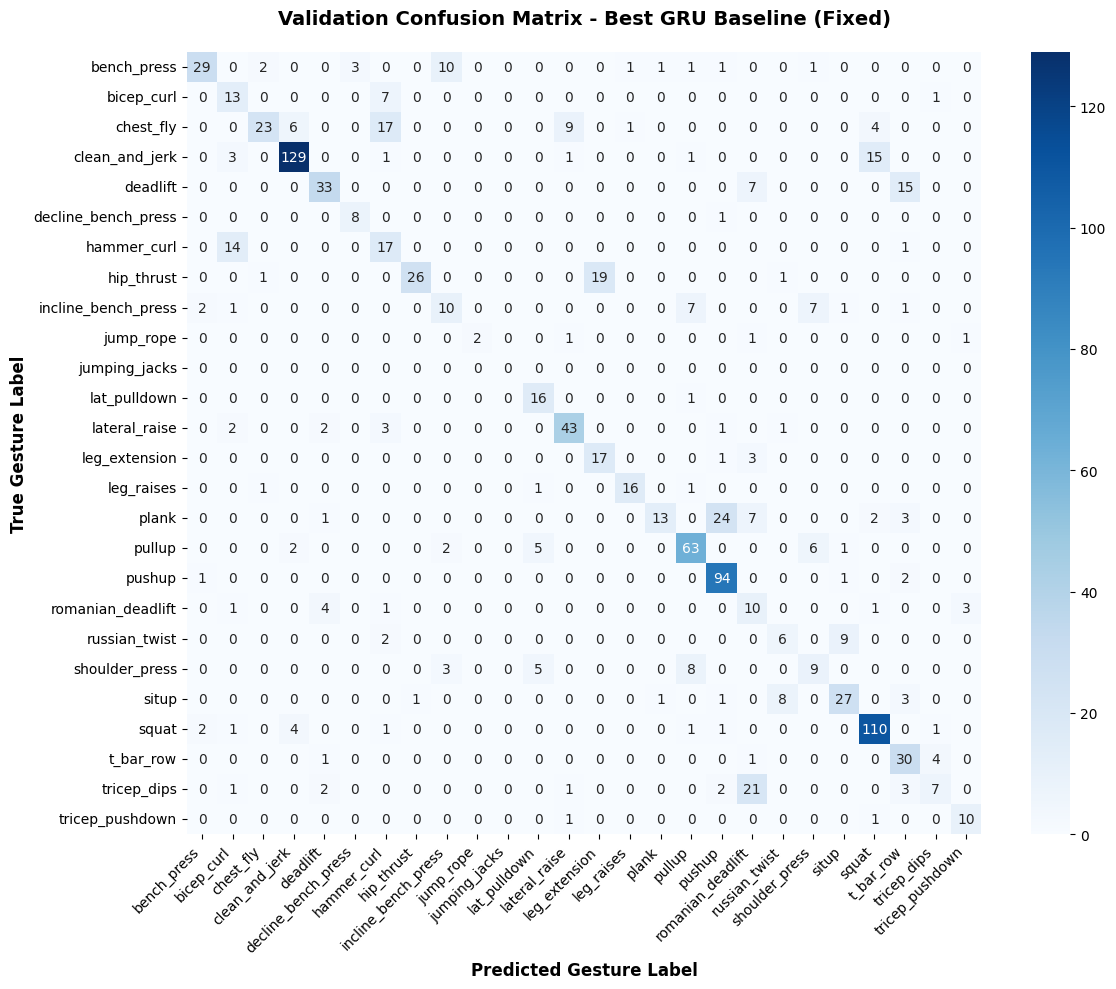


Detailed Classification Report for this Model:
                     precision    recall  f1-score   support

        bench_press       0.85      0.59      0.70        49
         bicep_curl       0.36      0.62      0.46        21
          chest_fly       0.85      0.38      0.53        60
     clean_and_jerk       0.91      0.86      0.89       150
           deadlift       0.77      0.60      0.67        55
decline_bench_press       0.73      0.89      0.80         9
        hammer_curl       0.35      0.53      0.42        32
         hip_thrust       0.96      0.55      0.70        47
incline_bench_press       0.40      0.34      0.37        29
          jump_rope       1.00      0.40      0.57         5
      jumping_jacks       0.00      0.00      0.00         0
       lat_pulldown       0.59      0.94      0.73        17
      lateral_raise       0.77      0.83      0.80        52
      leg_extension       0.47      0.81      0.60        21
         leg_raises       0.89      

In [41]:
# =====================================================================
# Cell: Fixed Confusion Matrix & Classification Report
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# 1. ჩავტვირთოთ მოდელი
model_path = f'{BASE}/models/gru_lr_0.001_d0.3_l2_0.0001.keras'
print(f"Loading best model from: {model_path}")
best_model = load_model(model_path)

# 2. პროგნოზები
y_pred_probs = best_model.predict(X_val, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)

# უსაფრთხოებისთვის: ავიღოთ კლასების სრული ინდექსები (0-დან 25-მდე)
all_labels = list(range(len(classes)))

# 3. მატრიცა ფიქსირებული ლეიბლებით
cm = confusion_matrix(y_val_idx, y_pred_idx, labels=all_labels)

# 4. ვიზუალიზაცია
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Validation Confusion Matrix - Best GRU Baseline (Fixed)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Gesture Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Gesture Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig('/content/best_gru_val_confusion_matrix_fixed_1.png', dpi=200)
plt.show()

# 5. რეპორტი ფიქსირებული ლეიბლებით
print(f"\n{'='*60}\nDetailed Classification Report for this Model:\n{'='*60}")
print(classification_report(
    y_val_idx,
    y_pred_idx,
    labels=all_labels,      # აქ ვეუბნებით 26-ვე ლეიბლს
    target_names=classes,
    zero_division=0         # თუ კლასი აკლია, უბრალოდ 0 დაუწეროს
))

Loading best model from: /content/drive/MyDrive/Ketastasia/data/models/gru_lr_0.001_d0.3.keras


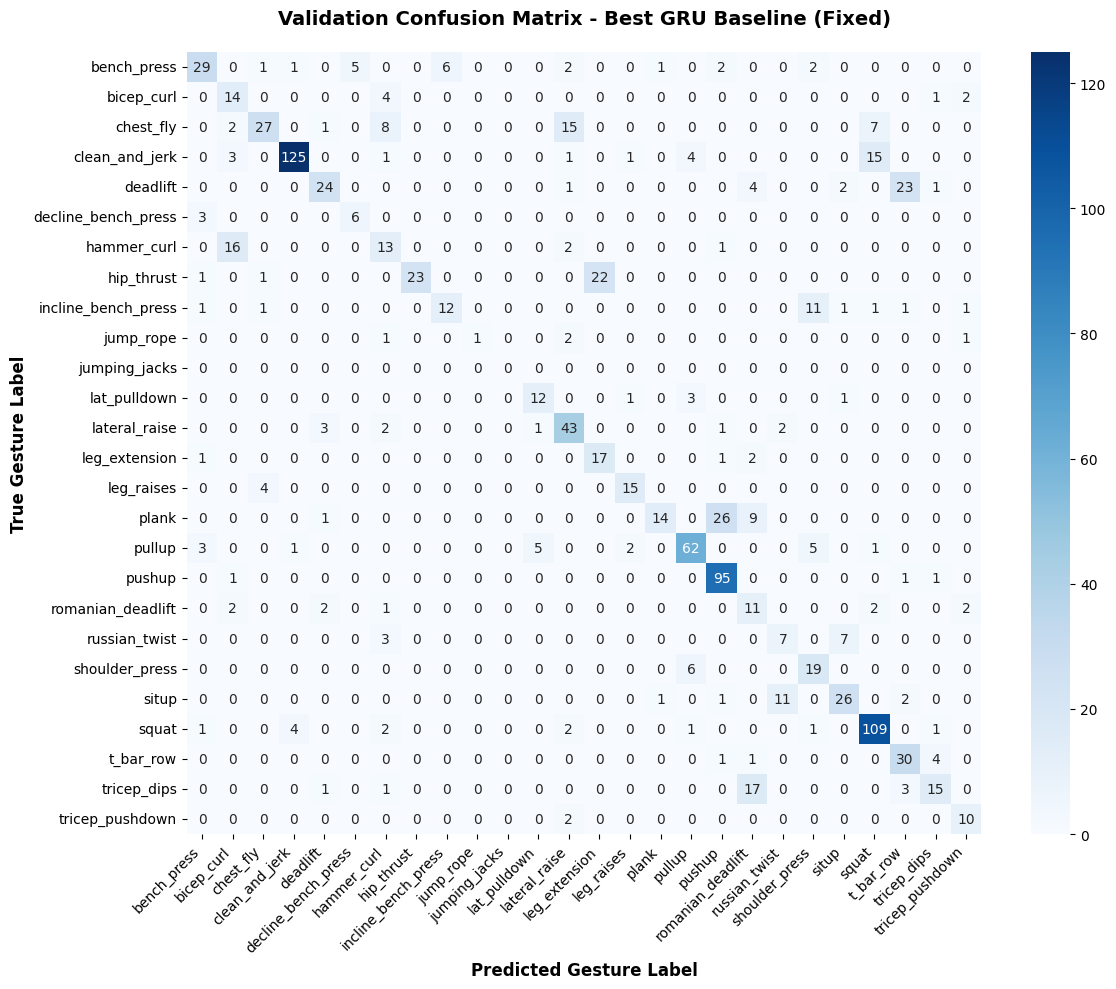


Detailed Classification Report for this Model:
                     precision    recall  f1-score   support

        bench_press       0.74      0.59      0.66        49
         bicep_curl       0.37      0.67      0.47        21
          chest_fly       0.79      0.45      0.57        60
     clean_and_jerk       0.95      0.83      0.89       150
           deadlift       0.75      0.44      0.55        55
decline_bench_press       0.55      0.67      0.60         9
        hammer_curl       0.36      0.41      0.38        32
         hip_thrust       1.00      0.49      0.66        47
incline_bench_press       0.67      0.41      0.51        29
          jump_rope       1.00      0.20      0.33         5
      jumping_jacks       0.00      0.00      0.00         0
       lat_pulldown       0.67      0.71      0.69        17
      lateral_raise       0.61      0.83      0.70        52
      leg_extension       0.44      0.81      0.57        21
         leg_raises       0.79      

In [42]:
# =====================================================================
# Cell: Fixed Confusion Matrix & Classification Report
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# 1. ჩავტვირთოთ მოდელი
model_path = f'{BASE}/models/gru_lr_0.001_d0.3.keras'
print(f"Loading best model from: {model_path}")
best_model = load_model(model_path)

# 2. პროგნოზები
y_pred_probs = best_model.predict(X_val, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)

# უსაფრთხოებისთვის: ავიღოთ კლასების სრული ინდექსები (0-დან 25-მდე)
all_labels = list(range(len(classes)))

# 3. მატრიცა ფიქსირებული ლეიბლებით
cm = confusion_matrix(y_val_idx, y_pred_idx, labels=all_labels)

# 4. ვიზუალიზაცია
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Validation Confusion Matrix - Best GRU Baseline (Fixed)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Gesture Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Gesture Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig('/content/best_gru_val_confusion_matrix_fixed_2.png', dpi=200)
plt.show()

# 5. რეპორტი ფიქსირებული ლეიბლებით
print(f"\n{'='*60}\nDetailed Classification Report for this Model:\n{'='*60}")
print(classification_report(
    y_val_idx,
    y_pred_idx,
    labels=all_labels,      # აქ ვეუბნებით 26-ვე ლეიბლს
    target_names=classes,
    zero_division=0         # თუ კლასი აკლია, უბრალოდ 0 დაუწეროს
))

In [47]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model

# 1. ფიჩერების ექსტრაქტორი (თუ მონაცემებს დამუშავება სჭირდება, ჩაწერე transform-ში)
class ExtendedFeatureExtractor:
    def __init__(self):
        pass
    def transform(self, X):
        return X

# 2. ერთიანი Custom პაიპლაინის კლასი (მყარი და დაცული ერორებისგან)
class GRUPipeline:
    def __init__(self, extractor, model_path):
        self.extractor = extractor
        self.model_path = model_path
        self._model = None

    def predict(self, X):
        # Lazy loading: მოდელი ჩაიტვირთება მხოლოდ მაშინ, როცა predict-ს გამოვიძახებთ
        if self._model is None:
            print(f"-> Loading Keras model from: {self.model_path}")
            self._model = load_model(self.model_path)

        # ფიჩერების ტრანსფორმაცია
        X_trans = self.extractor.transform(X)
        # მოდელის პროგნოზი
        preds_probs = self._model.predict(X_trans, verbose=0)
        return np.argmax(preds_probs, axis=1)

# 3. ვუთითებთ შენი 11%-იანი გეფის მქონე ჩემპიონი მოდელის ზუსტ გზას
saved_model_path = f'{BASE}/models/gru_lr_0.001_d0.3.keras'

# 4. ვქმნით პაიპლაინის ეგზემპლარს
p2_gru_pipeline = GRUPipeline(
    extractor=ExtendedFeatureExtractor(),
    model_path=saved_model_path
)

# 5. ვინახავთ ფაილად
joblib.dump(p2_gru_pipeline, "p2_gru_pipeline.pkl")
print("✅ პაიპლაინი წარმატებით შეინახა სახელით: p2_gru_pipeline.pkl")

✅ პაიპლაინი წარმატებით შეინახა სახელით: p2_gru_pipeline.pkl


In [48]:
import wandb

# 1. ვხსნით ახალ რანს სპეციალურად არტიფაქტის ასატვირთად
run = wandb.init(
    project="ildolcefarniente",
    group="p2_gru",
    name="upload_best_p2_gru_pipeline",
)

# 2. ვქმნით არტიფაქტს მოდელისთვის
artifact = wandb.Artifact(name="best_p2_gru_pipeline", type="model")
artifact.add_file("p2_gru_pipeline.pkl")

# 3. ავტვირთავთ არტიფაქტს და ვადებთ თეგებს (Registry-სთვის)
run.log_artifact(artifact, aliases=["latest", "best_p2_gru"])

# 4. ვხურავთ რანს
wandb.finish()
print("პაიპლაინი აიტვირთა WandB-ზე!")

პაიპლაინი აიტვირთა WandB-ზე!
